st127260 - Hau Cong Nguyen
## GitHub Repository

[View the GitHub Repository](https://github.com/HauuNguyen/A1_Prediction)

Task 1. Preparing the datasets - Download the Car Price dataset from Google classroom. Perform
loading, EDA, preprocessing, model selection, ···, inference. Grade will be given based on the how well
you adhere to best practices. There are some important coding considerations:
•For the feature owner, map First owner to 1, ..., Test Drive Car to 5
•For the feature fuel, remove all rows with CNG and LPG because CNG and LPG use a different
mileage system i.e., km/kg which is different from kmfeaturepl for Diesel and Petrol
•For the feature mileage, remove “kmpl” and convert the column to numerical type (e.g., float).
Hint: use df.mileage.str.split
•For the feature engine, remove “CC” and convert the column to numerical type (e.g., float)
•Do the same for max power
•For the feature brand, take only the first word and remove the rest
•Drop the feature torque, simply because Chaky’s company does not understand well about it
•You will found out that Test Drive Cars are ridiculously expensive. Since we do not want to
involve this, we will simply delete all samples related to it.
•Since selling price is a big number, it can cause your prediction to be very unstable. One trick
is to first transform the label using log transform, i.e.,
1 y = np . log ( df [ ' selling_price '])
2
•During inference/testing, you have to transform your predicted y backed before comparing with y
test, i.e.,
1 pred_y = np . exp ( pred_y )

LOADING DATASET

Check the first rows
- Column names
- Example values
- Loaded correctly

IMPORT LIBRARY

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [130]:
df = pd.read_csv('/Users/nchau/Documents/ML/A1_Prediction/Cars.csv')

In [131]:
# 1. Inspect Raw Data Structure & Missingness
print("DATASET OVERVIEW")
print("Dataset Shape:", df.shape)
print("\nData Types & Info:")
df.info()
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nFirst 5 Rows (Raw):")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe())

DATASET OVERVIEW
Dataset Shape: (8128, 13)

Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB

Missing Values Count:
name               0
year               0
selling_price      0
km_driven          0

The raw dataset has 8,128 rows and 13 columns. 
Features like mileage, engine, max_power, and torque contain string units (e.g., 'kmpl', 'CC', 'bhp') 
and have ~215-222 missing values each that need numeric parsing and downstream imputation.

REMOVE CNG & LPG
CNG and LPG vehicles were excluded because their mileage uses km/kg rather than km/l, making the mileage feature inconsistent with Diesel and Petrol vehicles.

In [132]:
df = df[~df["fuel"].isin(["CNG", "LPG"])]

REMOVE TEST DRIVE CARS
Test Drive Cars were removed because their selling prices are unusually high compared with normal used cars and could distort the price prediction model.

In [133]:
df = df[df["owner"] != "Test Drive Car"]

CREATE THE brand FEATURE
Currently we have 

Maruti Swift Dzire VDI
Skoda Rapid 1.5 TDI Ambition
Honda City 2017-2020 EXi
Hyundai i20 Sportz Diesel

---> Assignemnt require: take only the first word and remove the rest.

In [134]:
df["brand"] = df["name"].str.split().str[0]
df[["name", "brand"]].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


DROP name
The name feature was removed after extracting the first word as brand. Keeping the full car name would create a very high-cardinality categorical feature and could make the model unnecessarily complex.

In [135]:
df = df.drop(columns=["name"])

DROP torque
The torque feature was removed because its values contain inconsistent textual formats and require additional parsing. Since the assignment does not require torque processing, it was excluded to avoid introducing unreliable information into the model.

In [136]:
df = df.drop(columns=["torque"])

CLEAN mileage
Assigment require: remove kmpl and convert the column to numerical type.

In [137]:
df["mileage"] = df["mileage"].str.split().str[0].astype(float)

In [138]:
#check
df["mileage"].dtype

dtype('float64')

CLEAN engine

In [139]:
df["engine"] = df["engine"].str.replace(" CC", "", regex=False).astype(float)

In [140]:
#check
df["engine"].dtype

dtype('float64')

CLEAN max_power

In [141]:
df["max_power"] = df["max_power"].str.replace(" bhp", "", regex=False)
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

In [142]:
df["max_power"].dtype

dtype('float64')

RE-CHECK MISSING VALUES

In [143]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
brand              0
dtype: int64

CLEAN owner
Assignment require: map First Owner to 1, ..., Test Drive Car to 5.

In [144]:
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4
}

df["owner"] = df["owner"].map(owner_mapping)

CHECK CATEGORICAL COLUMNS

In [145]:
df.dtypes

year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner              int64
mileage          float64
engine           float64
max_power        float64
seats            float64
brand             object
dtype: object

EDA
- Target: selling_price

In [146]:
df["selling_price"].describe()

count    8.028000e+03
mean     6.403937e+05
std      8.027015e+05
min      2.999900e+04
25%      2.600000e+05
50%      4.500000e+05
75%      6.800000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

1. Distribution of selling price

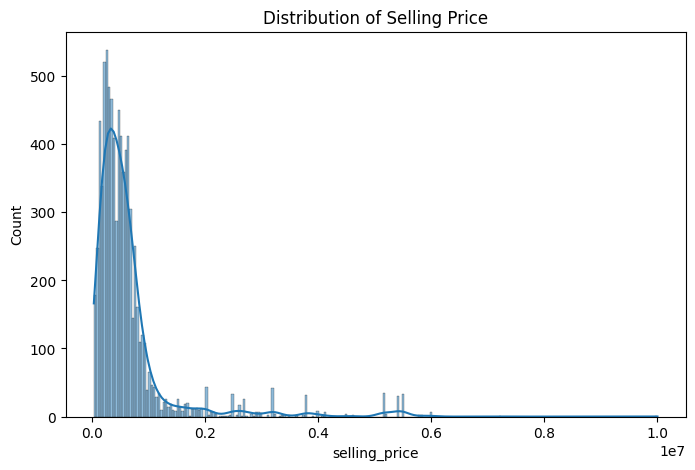

In [147]:
plt.figure(figsize=(8, 5))
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

The selling price distribution is strongly right-skewed, with most vehicles concentrated at lower prices and a smaller number of expensive vehicles. This motivates the use of a log transformation on the target variable.

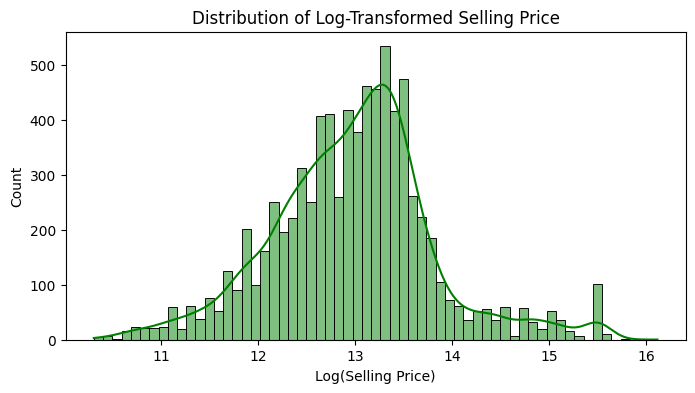

In [148]:
# Plot log-transformed target variable distribution
plt.figure(figsize=(8, 4))
sns.histplot(np.log(df['selling_price']), kde=True, color='green')
plt.title('Distribution of Log-Transformed Selling Price')
plt.xlabel('Log(Selling Price)')
plt.show()

The log transformation reduces the strong right skew in the selling price distribution, making the target distribution more balanced for model training.

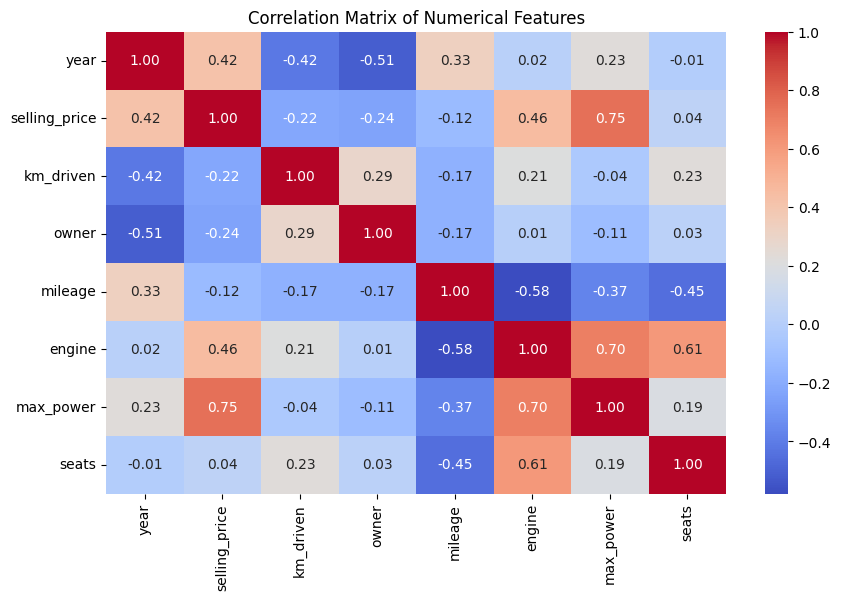

In [172]:
# Correlation heatmap for continuous numerical variables
numeric_cols = ['year', 'selling_price', 'km_driven','owner', 'mileage', 'engine', 'max_power', 'seats']
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation matrix shows that max_power and engine have relatively strong positive correlations with selling_price. This suggests that cars with higher engine capacity and greater power tend to have higher selling prices. However, correlation does not imply causation.

SEPARATE THE TARGET, TRAIN/TEST SPLIT
- Target: selling price

In [150]:
X = df.drop(columns=["selling_price"])
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

CREATE THE TRANSFORM TARGET

In [151]:
y_train_log = np.log(y_train)

Only scale continuous numerical features.

In [152]:
# numeric_features = [
#     "year",
#     "km_driven",
#     "owner",
#     "mileage",
#     "engine",
#     "max_power",
#     "seats"
# ]
numeric_features = [
    "km_driven",
    "mileage",
    "engine",
    "max_power"
]

In [153]:
other_numeric_features = [
    "year",
    "owner",
    "seats"
]

In [154]:
categorical_features = [
    "brand",
    "fuel",
    "seller_type",
    "transmission"
]

CREATE THE NUMERICAL PREPROCESSING PIPELINE

In [155]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [156]:
other_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

The dataset contains missing numerical values.

We need to fill them before the model can use those columns.

CREATE THE CATEGORICAL PREPROCESSING PIPELINE

In [157]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

OneHotEncoder - Because categories don't have a natural numerical order.

COMBINE BOTH PIPELINE

In [158]:
from sklearn.compose import ColumnTransformer

# preprocessor = ColumnTransformer([
#     ("num", numeric_pipeline, numeric_features),
#     ("cat", categorical_pipeline, categorical_features)
# ])
preprocessor = ColumnTransformer([
    ("continuous", numeric_pipeline, numeric_features),
    ("other_numeric", other_numeric_pipeline, other_numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

DEFINE MODELS

In [159]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "SVR": SVR()
}

COMPARE MODELS USING CROSS-VALIDATION

In [160]:
from sklearn.model_selection import cross_val_score

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train_log,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    results.append({
        "Model": name,
        "CV RMSE": -scores.mean()
    })

In [161]:
results_df = pd.DataFrame(results)

results_df.sort_values("CV RMSE")

,Model,CV RMSE
2,Random Forest,0.213107
3,Gradient Boosting,0.226682
0,Linear Regression,0.258175
1,Ridge,0.258240
4,SVR,0.818603


GridSeachCV ON THE SELECTED MODEL

In [162]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [163]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [164]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train_log)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('continuous',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['km_driven',
                                                                          'mileage',
                                                                          'engine',
                                                                          'max_power']),
                                                                        ('other_numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent'))]),
                                                                         ['year',
                                                                          'owner',
                                                                          'sea...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['brand',
                                                                          'fuel',
                                                                          'seller_type',
                                                                          'transmission'])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [165]:
grid_search.best_params_

{'model__max_depth': 20,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 5,
 'model__n_estimators': 200}

In [170]:
best_model = grid_search.best_estimator_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

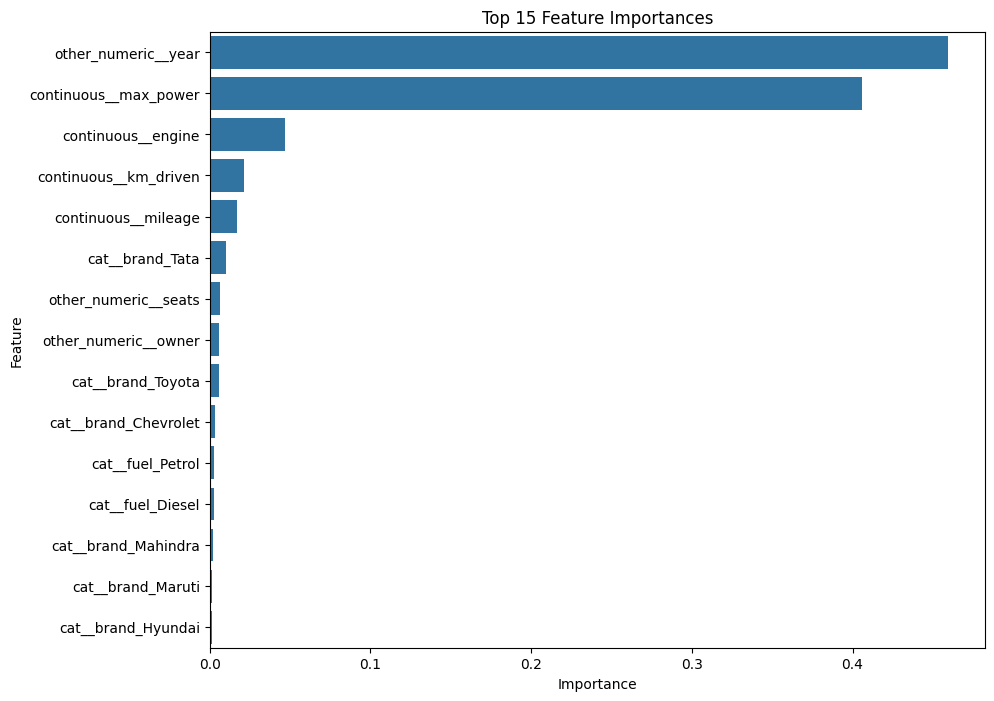

In [171]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.show()

FINAL TEST PREDICTION

In [166]:
predicted_log_price = grid_search.predict(X_test)

Convert predictions back to the original price scale

The model predicts the log-transformed selling price, so we use "np.exp()" to convert the predictions back to the original selling-price scale before calculating the final evaluation metrics.

In [167]:
predicted_price = np.exp(predicted_log_price)

FINAL EVALUATION

In [168]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predicted_price)
rmse = np.sqrt(mean_squared_error(y_test, predicted_price))
r2 = r2_score(y_test, predicted_price)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 69043.28276150848
RMSE: 204713.90861914854
R²: 0.945870196637393


FINAL ACTUAL-VS-PREDICTED PLOT

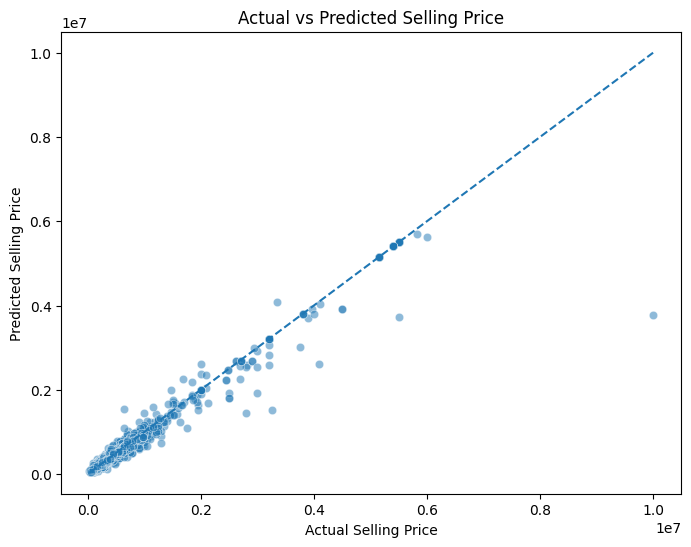

In [169]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=predicted_price,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [173]:
best_model = grid_search.best_estimator_

In [177]:
import joblib

joblib.dump(
    best_model,
    "project/app/code/car_price_model.joblib"
)

['project/app/code/car_price_model.joblib']

Task 2:

The feature importance results show that "year" is the most important feature for predicting car selling price, followed by "max_power" and "engine". This suggests that the vehicle's model year and its performance-related characteristics are important factors in determining its price.. "km_driven" and "mileage" also contribute to the predictions, but their importance is lower. The individual categorical brand features have relatively small importance compared with the main numerical features. Overall, the results suggest that the results indicate that model year, engine capacity, and power are strongly associated with the model's predicted selling price..

Among the models tested, Random Forest performed the best, achieving the lowest cross-validation RMSE of 0.2131. Gradient Boosting was the second-best model with a CV RMSE of 0.2267, while Linear Regression and Ridge had similar results of about 0.258. SVR performed the worst with a CV RMSE of 0.8186. Random Forest likely performed well because it can capture nonlinear relationships and interactions between features, which are common in car prices. In contrast, the linear models assume simpler relationships between the features and price, which may not fully represent the factors affecting car prices.

After selecting Random Forest, GridSearchCV was used to tune its hyperparameters. The final tuned model was evaluated on the untouched test set and achieved an MAE of approximately 69,043, an RMSE of approximately 204,714, and an R² of 0.946. This means the model explains about 94.6% of the variation in selling prices. The actual-versus-predicted plot shows that most predictions are close to the ideal prediction line, although the model has larger errors for some high-priced vehicles. Overall, Random Forest provided the strongest performance among the tested models, but predicting unusually expensive cars remains more difficult.